In [1]:
#Quick sanity check

print("all is well")

all is well


## RAG BASICS

In [2]:
# Read the .env file and load the environment variables
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
# Using Langchain's Google Generative AI Embeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings

#Initializing the embedding model with the specific embedding model "models/gemini-embedding-001"
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# Convert a smaple query to numerical vector representation using the embedding model
vector = embeddings.embed_query("What is RAG?")

#Display the first 5 dimensions of the resulting embedding vector
print(vector[:5])

[-0.0050992095, 0.012719812, -0.015219515, -0.056661323, -0.010068115]


## 1. Data Ingestion

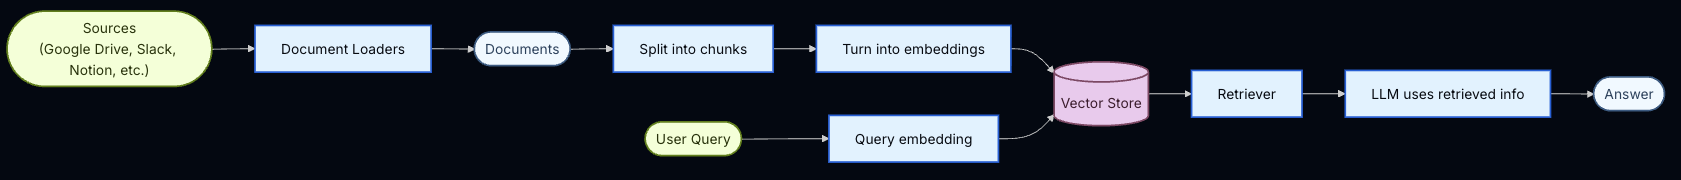

In [5]:
# Import PDF leaders to read and process PDF documents page by page
from langchain_community.document_loaders import PyPDFLoader
import os

# Import text splitter to break large documents into smaller chunks for better processing and embedding
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [6]:
#Verify the current working directory
os.getcwd()

'/Users/2099070/Documents/Cognizant/12 May - RAG Basics'

In [7]:
# Build the full file path to the PDF document
file_path=os.path.join(os.getcwd(),"2511.09030v1.pdf")

In [8]:
file_path

'/Users/2099070/Documents/Cognizant/12 May - RAG Basics/2511.09030v1.pdf'

In [9]:
# Create a PDF loader and load the document (each page becomes a separate Document object)
loader = PyPDFLoader(file_path)
document = loader.load()
#PREVIEW THE 11TH PAGE (INDEX 10) TO INSPECT THE LOADED CONTENT
document[10]

Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:4177c2c)', 'creationdate': '', 'author': 'Elliot Meyerson; Giuseppe Paolo; Roberto Dailey; Hormoz Shahrzad; Olivier Francon; Conor F. Hayes; Xin Qiu; Babak Hodjat; Risto Miikkulainen', 'doi': 'https://doi.org/10.48550/arXiv.2511.09030', 'license': 'http://creativecommons.org/licenses/by/4.0/', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) kpathsea version 6.4.1', 'title': 'Solving a Million-Step LLM Task with Zero Errors', 'trapped': '/False', 'arxivid': 'https://arxiv.org/abs/2511.09030v1', 'source': '/Users/2099070/Documents/Cognizant/12 May - RAG Basics/2511.09030v1.pdf', 'total_pages': 29, 'page': 10, 'page_label': '11'}, page_content='Solving a Million-Step LLM Task with Zero Errors\nFigure 7:A snapshot of the million-step problem-solving process.The dots in the background represent the steps,\nordered in rows from top to bottom. At step 479,806, MAKER is near t

In [10]:
# Configure the text splitter to break documents into chunks of 1000 characters
# with 200-character overlap to preserve context across chunk boundaries
# Note: chunk_size and chunk_overlap are experimental — no deterministic best values yet
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, 
    chunk_overlap=200, 
    length_function=len
    )

In [11]:
# Split the loaded PDF into smaller, overlapping chunks
docs = text_splitter.split_documents(document)

In [12]:
docs

[Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:4177c2c)', 'creationdate': '', 'author': 'Elliot Meyerson; Giuseppe Paolo; Roberto Dailey; Hormoz Shahrzad; Olivier Francon; Conor F. Hayes; Xin Qiu; Babak Hodjat; Risto Miikkulainen', 'doi': 'https://doi.org/10.48550/arXiv.2511.09030', 'license': 'http://creativecommons.org/licenses/by/4.0/', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) kpathsea version 6.4.1', 'title': 'Solving a Million-Step LLM Task with Zero Errors', 'trapped': '/False', 'arxivid': 'https://arxiv.org/abs/2511.09030v1', 'source': '/Users/2099070/Documents/Cognizant/12 May - RAG Basics/2511.09030v1.pdf', 'total_pages': 29, 'page': 0, 'page_label': '1'}, page_content='SOLVING AMILLION-STEPLLM TASK WITHZEROERRORS\nElliot Meyerson∗\nCognizant AI Lab\nGiuseppe Paolo\nCognizant AI Lab\nRoberto Dailey\nCognizant AI Lab\nHormoz Shahrzad\nUT Austin & Cognizant AI Lab\nOlivier Francon\nCognizant AI Lab\n

In [13]:
#Compare:number of original pages vs. number of chunks after splitting
len(document), len(docs)

(29, 121)

## 2. Create Embeddings

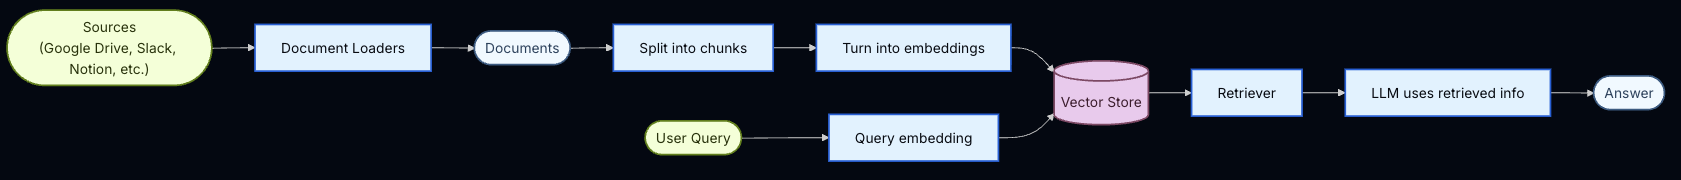

In [15]:
# Re-initialize the LangChain embedding model for use with the vector store
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

In [16]:
# Generate embeddings for the first page's content to verify the model works on document text
embeddings.embed_documents([document[0].page_content])

[[0.00046089847,
  0.010594814,
  0.0088606225,
  -0.06263413,
  -0.0013029354,
  -0.0065867454,
  0.007914569,
  0.018524582,
  -0.009563708,
  -0.008054766,
  -0.00014050759,
  -0.0048852596,
  0.0015467331,
  0.014003588,
  0.12991402,
  0.029848563,
  -0.005712257,
  0.026714602,
  -0.0010148985,
  -0.020093095,
  0.007542626,
  -0.0060863174,
  -0.001655353,
  0.007670103,
  -0.002388175,
  0.031532396,
  -0.000518902,
  0.004200928,
  0.048327696,
  0.006031878,
  -0.0047452934,
  0.012352514,
  -0.0071192402,
  0.014749078,
  0.0016612422,
  0.0010594238,
  0.011897188,
  0.007903005,
  0.005377324,
  0.023039863,
  -0.0066647525,
  -0.0028411394,
  -0.008057856,
  -0.007711745,
  -0.0051586325,
  0.013600548,
  0.004926917,
  -0.050545704,
  -0.0004261576,
  0.017926104,
  0.0135586355,
  0.0260346,
  -0.002285677,
  -0.17010807,
  -0.004702517,
  -0.0068058996,
  -0.011253389,
  -0.0006548296,
  0.014065044,
  -0.010055437,
  -0.004399641,
  0.0057360865,
  -0.0051436466,
  -0

## 3. Build a Vector Store

In [19]:
# FAISS is a fast, in-memory vector similarity search library
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

# Build a FAISS vector store by embedding all document pages and indexing them
vector_store = FAISS.from_documents(
document, embeddings  # embeds each document and stores the vectors
)

## 4. Similarity Search

In [20]:
# Perform a similarity search: find the top 8 most relevant document chunks for the query
relevant_document=vector_store.similarity_search("What is this document about?", k=8)

In [21]:
# Display the text content of the most relevant document chunk
relevant_document[0].page_content

'Meyerson, et al.\ndef _validate_state(state):\nif not (isinstance(state, list) and len(state) == 3 and all(isinstance(t, list) for t in\nstate)):\nraise ValueError("’next_state’ must be a list of three lists.")\nflat = [x for t in state for x in t]\nif not all(isinstance(x, int) for x in flat):\nraise ValueError("All entries in ’next_state’ must be integers.")\nif len(flat) != 20 or set(flat) != set(range(1, 21)):\nmissing = sorted(set(range(1, 21)) - set(flat))\nextra = sorted(set(flat) - set(range(1, 21)))\nraise ValueError("State must contain 1..20 exactly once. "\nf"Missing: {missing or ’[]’}, Extras: {extra or ’[]’}")\nreturn state\ndef parse_move_state_flag(response_text: str):\n# Match square brackets\nmove_pat = re.compile(r"(?is)\\bmove\\b\\s*=\\s*(\\[[^\\[\\]]*\\])")\nstate_pat = re.compile(\nr"(?is)\\bnext_state\\b\\s*=\\s*(\\[\\s*\\[[^\\[\\]]*\\]\\s*,\\s*\\[[^\\[\\]]*\\]\\s*,\\s*\\[[^\\[\\]]*\\]\\s\n*\\])"\n)\nmove_matches = list(move_pat.finditer(response_text))\nif not m

In [22]:
# Convert the vector store into a LangChain retriever for use in a RAG chain
retriever=vector_store.as_retriever()

In [23]:
# Test the retriever by querying it directly — returns the most relevant document chunks
retriever.invoke("Gemini Finetuning benchmarking experiments") 

[Document(id='9334a695-50bd-4ce1-a945-1bbf8218f87f', metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:4177c2c)', 'creationdate': '', 'author': 'Elliot Meyerson; Giuseppe Paolo; Roberto Dailey; Hormoz Shahrzad; Olivier Francon; Conor F. Hayes; Xin Qiu; Babak Hodjat; Risto Miikkulainen', 'doi': 'https://doi.org/10.48550/arXiv.2511.09030', 'license': 'http://creativecommons.org/licenses/by/4.0/', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) kpathsea version 6.4.1', 'title': 'Solving a Million-Step LLM Task with Zero Errors', 'trapped': '/False', 'arxivid': 'https://arxiv.org/abs/2511.09030v1', 'source': '/Users/2099070/Documents/Cognizant/12 May - RAG Basics/2511.09030v1.pdf', 'total_pages': 29, 'page': 9, 'page_label': '10'}, page_content='Meyerson, et al.\n0.2\n0.4\n10 12 14 16 18 20\n# Disks\n0.000\n0.002\n0.004\n0.006\n0.008              Single-step Error Rate 1 p\ngpt-4.1-nano (mean=0.3583)\ngpt-4.1-mini (mean=0.0045)\no

## 5. Create Prompt

In [25]:
# Define a prompt template that instructs the LLM to answer based only on retrieved context
# {context} will be filled with relevant document chunks, {question} with the user's query
prompt_template = """
Answer the question based on the context below.
If the context does not contain sufficient information, respond with: "I don't have sufficient information".
Context: {context}
Question: {question}
Answer: """

In [26]:
# Create a LangChain PromptTemplate object from the template string
from langchain_core.prompts import PromptTemplate
prompt=PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]  # variables that will be substituted at runtime
)

In [27]:
# Inspect the prompt template object to verify its structure
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='\nAnswer the question based on the context below.\nIf the context does not contain sufficient information, respond with: "I don\'t have sufficient information".\nContext: {context}\nQuestion: {question}\nAnswer: ')

## 6. Create a RAG Chain

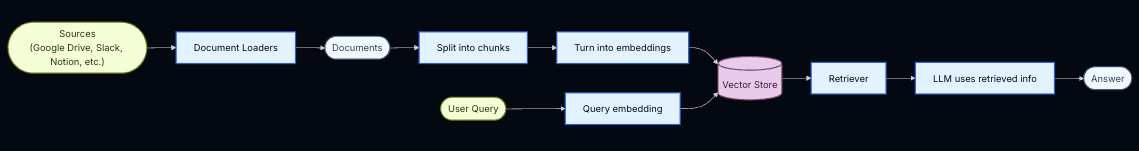

In [28]:
# StrOutputParser converts the LLM's response object into a plain string
from langchain_core.output_parsers import StrOutputParser
# RunnablePassthrough passes the input through unchanged — used to forward the question in the chain
from langchain_core.runnables import RunnablePassthrough
# Instantiate the output parser to extract plain text from LLM responses
parser = StrOutputParser()

In [29]:
# Helper function to concatenate retrieved document chunks into a single context string
def format_docs(texts):
    return "\n\n".join([doc.page_content for doc in texts])

In [30]:
# Initialize the Gemini LLM for generating answers
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# Build the RAG chain using LangChain Expression Language (LCEL):
# 1. Retrieve relevant docs and format them as context; pass the question through unchanged
# 2. Fill the prompt template with context + question
# 3. Send the filled prompt to the LLM
# 4. Parse the LLM output into a plain string
rag_chain = ( 
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
    )

In [ ]:
# Run the full RAG pipeline: retrieve → format → prompt → LLM → parse
rag_chain.invoke("What is this document about?")